In [1]:
import sys

sys.path.append("..")

from itertools import product
import pickle
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import torch
import seaborn as sns
from tabpfn import TabPFNRegressor
from mlresearch.datasets import BinaryDatasets, ContinuousCategoricalDatasets
from mlresearch.utils import set_matplotlib_style
from explainerpfn.base import ExplainerPFN
from explainerpfn.train import SyntheticDataGenerator

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Device is set to CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


random_state = 42
max_samples = 20000
max_features = 15
model_path = "../../explainerpfn_model_NOV_15.ckp"
rng = np.random.default_rng(random_state)

set_matplotlib_style(use_latex=False, font_size=18, **{"font.family":"serif"})

No GPU available. Device is set to CPU.


## Functions copied from notebook 8 (analysis across datasets)

In [2]:
def top_k_jaccard_similarity(arr1, arr2, k=3):
    if arr1.ndim == 1:
        arr1 = arr1.reshape(1, -1)
    if arr2.ndim == 1:
        arr2 = arr2.reshape(1, -1)

    feats1 = np.argpartition(arr1, -k, axis=1)[:, -k:]
    feats2 = np.argpartition(arr2, -k, axis=1)[:, -k:]

    intersection = [np.intersect1d(row1, row2).shape[0] for row1, row2 in zip(feats1, feats2)]
    union = [row1.shape[0] + row2.shape[0] - intersect for row1, row2, intersect in zip(feats1, feats2, intersection)]
    return np.array(intersection) / np.array(union)


def get_results_tables(
    results_dict,
    jaccard_perc=1/3
):
    model_names = [
        key for key in list(results_dict.values())[0]
        if not (
            key.startswith("X_") or key.startswith("y_") or key == "model" or key == "base_model" or key.endswith("_time")
        )
    ]

    # Compute metrics
    mse = {}
    corr = {}
    jaccard = {}
    for dataset_name in results_dict:
        mse[dataset_name] = {}
        corr[dataset_name] = {}
        jaccard[dataset_name] = {}
        jaccard_k = max(1, int(results_dict[dataset_name]["X_test"].shape[1] * jaccard_perc))
        shap_values_test = results_dict[dataset_name]["shap"]
        for model_name in model_names:
            exp_values = results_dict[dataset_name][model_name]
            mse[dataset_name][model_name] = np.mean((exp_values - shap_values_test) ** 2)
            corr[dataset_name][model_name] = np.corrcoef(exp_values.ravel(), shap_values_test.ravel())[0, 1]
            jaccard[dataset_name][model_name] = np.mean(top_k_jaccard_similarity(exp_values, shap_values_test, k=jaccard_k))

    dataframes = []
    for metric in [mse, corr, jaccard]:
        df_metric = pd.DataFrame(metric)# .drop(["explainerpfn"])
        df_metric["Method"] = df_metric.index.map(lambda x: "_".join(x.split("_")[:-1]))
        df_metric["Samples"] = df_metric.index.map(lambda x: x.split("_n")[-1]).map(lambda x: int(x) if x.isdigit() else x.split("_")[-1])
        df_metric = df_metric[df_metric["Method"] != "shap"]
        df_metric = df_metric.set_index(["Method", "Samples"]).sort_index()
        dataframes.append(df_metric.copy())
    
    df_mse, df_corr, df_jaccard = dataframes
    return df_mse, df_corr, df_jaccard

## Datasets vs results analysis

In [3]:
datasets = BinaryDatasets().download()
datasets.content_ += ContinuousCategoricalDatasets().download().content_
content_processed = []
for name, df in datasets:
    # Drop Credit Approval dataset due to weird formatting issues
    if name == "CREDIT APPROVAL":
        continue

    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.str.startswith("cat")].copy()
    if df.target.nunique() > 2:
        df.target = (df.target == df.target.mode().iloc[0]).astype(int)
    
    if df.shape[1] < max_features and df.shape[1] > 2 and df.shape[0] < max_samples:
        content_processed.append((name, df))

datasets.content_ = content_processed
summary = datasets.summarize_datasets().sort_values(by="Observations")
summary

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

Datasets:   0%|          | 0/16 [00:00<?, ?it/s]

,Features,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,
ECHOCARDIOGRAM,8,61,17,44,2.59,2
HEPATITIS,4,129,24,105,4.38,2
FLAGS,10,194,60,134,2.23,2
HEART,6,270,120,150,1.25,2
HEART DISEASE,5,740,357,383,1.07,2
ANNEALING,6,798,190,608,3.20,2
GERMAN CREDIT,7,1000,300,700,2.33,2
BANKNOTE AUTHENTICATION,4,1372,610,762,1.25,2
CONTRACEPTIVE,5,1473,629,844,1.34,2


In [4]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results_mlp = pickle.load(f)

df_mse_mlp, df_corr_mlp, df_jaccard_mlp = get_results_tables(results_mlp)
# df_corr = df_corr.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
# df_jaccard = df_jaccard.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")

In [5]:
def result_formatting(df):
    df = (
        df
        .drop(index=["mlp", "rfr", "tabpfn"])
        .reset_index()
        .drop(columns=["Method"])
        .rename(columns={"Samples": "Method"})
        .set_index("Method")
        .drop("shap")
        .T
        .rename(columns={
            "explainerpfn": "Raw outputs",
            "additive": "Additivity",
            "statistical+additive": "Post-processed",
        })
        .copy()
    )
    df.columns.name = None
    return df

<Axes: xlabel='Observations', ylabel='Correlation'>

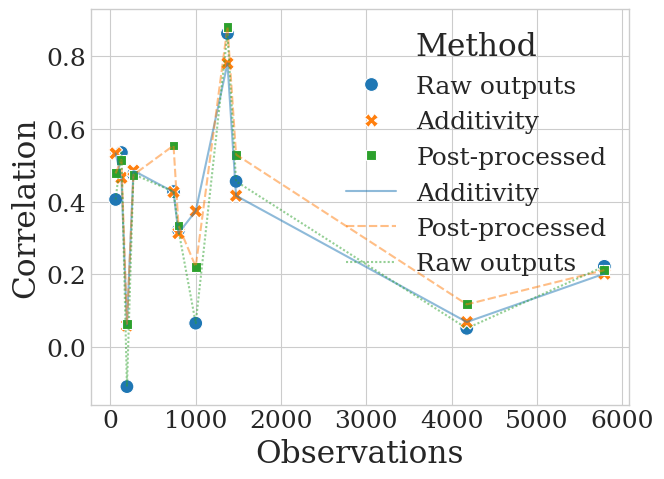

In [6]:
x_var = "Observations"

df_ = result_formatting(df_corr_mlp).join(summary[["Features", "Observations"]])
df_ = df_.sort_values(by="Features").melt(id_vars=["Features", "Observations"], var_name="Method", value_name="Correlation")
ax = sns.scatterplot(data=df_, x=x_var, y="Correlation", hue="Method", style="Method", s=100)

df2_ = df_.groupby([x_var, "Method"]).mean().reset_index()
sns.lineplot(data=df2_, x=x_var, y="Correlation", hue="Method", style="Method", alpha=0.5, ax=ax)

## Test over Synthetic datasets

In [7]:
# Collect datasets
n_features_list = list(range(2, 20, 2))
n_observations_list = list(range(50, 5_000, 300))

data = {
    "n_features": [],
    "n_samples": [],
    "X": [],
    "y": [],
    "y_pred": [],
    "shap": [],
}

for n_features, n_samples in tqdm(list(product(n_features_list, n_observations_list))):
    generator = SyntheticDataGenerator(
        n_features=[n_features, n_features+1],
        n_train_samples=[n_samples, n_samples+1],
        n_test_samples=0,
        successor_as_target=[True], 
        random_state=random_state
    ).generate(1)

    data["n_features"].append(n_features)
    data["n_samples"].append(n_samples)
    data["X"].append(generator.X_[0])
    data["y"].append(generator.y_[0])
    data["y_pred"].append(generator.y_pred_[0])
    data["shap"].append(generator.explanations_[0])

with open("ablations_synthetic_datasets.pkl", "wb") as f:
    pickle.dump(data, f)

  0%|          | 0/153 [00:00<?, ?it/s]

ExactExplainer explainer: 2151it [00:10, 12.84it/s]                           
ExactExplainer explainer: 2451it [00:12, 26.85it/s]                           
ExactExplainer explainer: 2751it [00:11, 20.05it/s]                           
ExactExplainer explainer: 3051it [00:23, 56.56it/s]                           
ExactExplainer explainer: 3351it [00:20, 98.39it/s]                           
ExactExplainer explainer: 3651it [00:17, 83.29it/s]                           
ExactExplainer explainer: 3951it [00:20, 84.96it/s]                           
ExactExplainer explainer: 4251it [00:25, 95.18it/s]                           
ExactExplainer explainer: 4551it [00:26, 92.38it/s]                           
ExactExplainer explainer: 4851it [00:24, 106.85it/s]                          
ExactExplainer explainer: 951it [00:10,  5.66it/s]                         
ExactExplainer explainer: 1251it [00:17, 37.80it/s]                          
ExactExplainer explainer: 1551it [00:26, 36.15it/s]     

In [27]:
# Get ExplainerPFN explanations
with open("ablations_synthetic_datasets.pkl", "rb") as f:
    data = pickle.load(f)

results = {
    "n_features": data["n_features"],
    "n_samples": data["n_samples"],
    "EPFN_raw": [],
    "EPFN_statistical": [],
    "EPFN_additive": [],
    "EPFN_statistical+additive": [],
    "TabPFN_02": [],
    "TabPFN_10": [],
}
for i in tqdm(range(len(data["X"]))):
    X = data["X"][i].values
    y_scores = data["y_pred"][i]

    xai = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
    xai.fit(X, y_scores)
    exp_pfn_values = xai.predict(X, y_scores)

    # ExplainerPFN variants
    results["EPFN_raw"].append(exp_pfn_values / np.sqrt(X.shape[1]))  # Normalize by number of features
    results["EPFN_statistical"].append(xai.apply_correction(y_scores, exp_pfn_values, kind=["statistical"]))
    results["EPFN_additive"].append(xai.apply_correction(y_scores, exp_pfn_values - exp_pfn_values.mean(axis=0), kind=["additive"]))
    results["EPFN_statistical+additive"].append(xai.apply_correction(y_scores, exp_pfn_values, kind=["statistical", "additive"]))

    # Few-shot TabPFN
    Xy = np.hstack([X, y_scores.reshape(-1, 1)])
    for n_train_samples in [2, 10]:
        train_idxs = rng.choice(np.arange(X.shape[0]), size=n_train_samples, replace=False)

        explanations_sample = data["shap"][i].values[train_idxs]
        Xy_sample = Xy[train_idxs]

        tabpfn_preds = np.zeros(X.shape, dtype=float)
        for col_idx in range(X.shape[1] - 1): 
            tabpfn = TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device)
            exp_target = explanations_sample[:, col_idx]

            tabpfn.fit(Xy_sample, exp_target)

            pred = tabpfn.predict(Xy)
            tabpfn_preds[:, col_idx] = pred

        results[f"TabPFN_{n_train_samples:02d}"].append(tabpfn_preds)

with open("ablations_synthetic_datasets_results.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/153 [00:00<?, ?it/s]

/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/tabpfn/architectures/base/preprocessing.py:320: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(np.log(-(2 - lmbda) * x[~pos] + 1) / (2 - lmbda))
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/tabpfn/architectures/base/preprocessing.py:320: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(np.log(-(2 - lmbda) * x[~pos] + 1) / (2 - lmbda))
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/tabpfn/architectures/base/preprocessing.py:320: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(np.log(-(2 - lmbda) * x[~pos] + 1) / (2 - lmbda))
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/tabpfn/architectures/base/preprocessing.py:320: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(np.log(-(2 - lmbda) * x[~pos] + 1) / (2 - lmbda))


KeyboardInterrupt: 

In [28]:
with open("ablations_synthetic_datasets_results_SAMPLE.pkl", "wb") as f:
    pickle.dump(results, f)

In [20]:
X

array([[-0.67193912, -0.43369222, -0.10031638,  0.48392809],
       [ 2.5885778 , -0.99710287,  0.3718589 , -0.14960398],
       [-0.40186057, -0.95773104, -0.48753877, -1.90196985],
       ...,
       [-0.63447781, -1.15572942, -0.82689818, -1.06396889],
       [-0.66097894,  0.58143039,  0.0460335 ,  0.60686749],
       [ 0.80470196, -0.75455886,  0.81417121, -0.0590044 ]],
      shape=(950, 4))

In [25]:
data["X"][i]

,dep_21,dep_18,dep_1,dep_8
0,-0.030026,-1.276667,-0.423090,1.681424
1,-0.794886,-0.720664,-0.976960,-0.109253
2,-0.135405,-0.254198,-0.938255,-1.670765
3,1.511010,-0.874798,-0.489708,-0.716803
4,0.592734,1.102139,-0.005636,-1.430942
...,...,...,...,...
645,-0.541526,-1.216680,1.323125,-0.002665
646,0.597970,-1.472045,0.008015,-0.913991
647,-1.542975,0.943970,-1.713804,-0.988602
648,1.751827,1.026113,0.547493,-0.247817


In [17]:
data["shap"][i]

,dep_21,dep_18,dep_1,dep_8
0,0.007970,-0.042764,0.002174,-0.471776
1,-0.125970,0.131538,-0.011658,-0.013689
2,0.017083,0.084388,0.027557,0.353274
3,0.056284,0.163832,-0.004682,0.242174
4,0.005438,-0.056014,-0.008417,0.430945
...,...,...,...,...
645,-0.054603,0.032914,-0.003137,-0.038806
646,0.114348,-0.009072,0.000260,0.334057
647,-0.187047,-0.078809,-0.191210,0.279648
648,-0.079050,-0.165428,-0.003929,0.001351


In [14]:
xai.predict(X.values, y_scores)

array([[ 0.55783021,  0.28803313,  0.12191616,  0.13651694],
       [ 0.78552759,  0.47216058,  0.06748638,  0.06900586],
       [ 0.76515007, -0.48729095,  0.16280615,  0.11007162],
       [ 0.59094948,  1.13789344,  0.03905139,  0.24415372],
       [-0.04157744, -1.69946492,  0.05069874, -0.11945363],
       [-0.71158844, -0.79569471,  0.0369097 , -0.09149894],
       [ 0.95736676,  1.11386847,  0.0464101 ,  0.09330986],
       [ 0.41168422, -1.44668531,  0.05649009,  0.14298034],
       [-0.13948032, -1.51239145,  0.0532349 , -0.17026913],
       [-0.21613994,  0.80910951,  0.08279884,  0.05581586],
       [ 0.64979184,  0.11149571,  0.035767  , -0.01453367],
       [-0.43996993, -1.61476779,  0.01433058, -0.03139229],
       [ 1.07807076,  1.31214666,  0.14866599,  0.11617897],
       [ 0.30477452,  1.28714335,  0.06933801,  0.10080644],
       [ 0.14715794,  1.08155775,  0.1354872 ,  0.10214393],
       [-0.06803299,  0.66232949,  0.01989007,  0.04244697],
       [-0.6608777 ,  0.